# Quantum Pong - 2DEG
This is a quick prototype made in Python. The point was to evaluate how numerically expensive this process would be. The conclusion was that I need GPU power for this.\n\n

The code to generate the Quantum Pong logo is also here

In [1]:
import scipy
import time
import numpy as np
# import numba
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import odeint
from scipy.special import jv

import pickle
from IPython.display import HTML
from PIL import Image, ImageDraw, ImageFont

In [2]:
SCALE = 4.2

class system():

    
    def set_geometry(self,Nx,Ny):
        self.Nx = Nx
        self.Ny = Ny

    
    def build_hop(self,dx,dy,hop):

        # number of elements in the x,y direction
        ex = self.Nx - abs(dx)
        ey = self.Ny - abs(dy)

        # Hamiltonian matrix
        hd = np.ones([ex,ey], dtype=complex)
        for i in range(ex):
            for j in range(ey):
                hd[i,j] = hop

        # Initial and final indices
        if dx > 0:
            sx = dx
            ex = 0
        else:
            sx = 0
            ex = -dx

        if dy > 0:
            sy = dy
            ey = 0
        else:
            sy = 0
            ey = -dy

        
        return [sx,sy,ex,ey,hd*1.0]


    def init_wavefunction(self):
        # the third argument is just an index to avoid unnecessary copying
        self.index = 0
        self.psi = np.zeros([self.Nx, self.Ny, 2], dtype=complex)
    
    def set_Hamiltonian(self):
        # The Hamiltonian is codified as a set of hopping matrices

        
        t = -1/SCALE
        self.H = []

        # Hopping to the right
        h = self.build_hop( 1, 0, t)
        self.H.append(h.copy())

        # Hopping to the left
        h = self.build_hop(-1, 0, t)
        self.H.append(h.copy())

        # Hopping up
        h = self.build_hop( 0, 1, t)
        self.H.append(h.copy())

        # Hopping down
        h = self.build_hop( 0,-1, t)
        self.H.append(h.copy())

    def mult_H(self, zero_flag, factor):
        i = self.index
        j = (self.index + 1)%2
        Nx = self.Nx
        Ny = self.Ny
        Nh = len(self.H)

        # Iterate over the Hamiltonian hoppings
        if zero_flag:
            self.psi[:,:,j] *= 0
        else:
            self.psi[:,:,j] *= -1
            
        for k in range(Nh):
            sx,sy,ex,ey = self.H[k][:-1]
            self.psi[sx:Nx-ex,sy:Ny-ey,j] += factor*self.H[k][-1]*self.psi[ex:Nx-sx,ey:Ny-sy,i]
        
        self.index = j

    
    # def cheb(self, n):
    #     # assumes 
        
    #     if n == 1:
    #         self.mult_H(True, 1)

    #     if n > 1:
    #         self.mult_H(False, 2)
            
            
    def cheb_coefs(self, coefs):
        Ncheb = len(coefs)
        if Ncheb == 0: return 

        # Chebyshev zero
        output = self.psi[:,:,self.index]*coefs[0]
        if Ncheb == 1: return 

        # Chebyshev one
        self.mult_H(True, 1)
        output += self.psi[:,:,self.index]*coefs[1]
        if Ncheb == 2: return 

        # All other Chebyshev coefficients
        for n in range(2,Ncheb):
            self.mult_H(False, 2)
            output += self.psi[:,:,self.index]*coefs[n]
            
        self.psi[:,:,self.index] = output*1.0
        

In [3]:
# a0 = 1
# t = -1
# a1 = a0*np.array([1,0])
# a2 = a0*np.array([0,1])

def conv(ar):
    y,x = ar.shape
    ar_c = ar.transpose()*0.0
    for i in range(x):
        for j in range(y):
            ar_c[i,j] = ar[j,x-i-1]
    
    return ar_c

Nx = 5
Ny = 4

sys = system()
sys.set_geometry(Nx,Ny)
sys.set_Hamiltonian()


In [4]:
sys.init_wavefunction()
i,j = 4,3
sys.psi[i,j,0] = 1

print(np.abs(conv(sys.psi[:,:,sys.index])))
print(sys.index)

sys.mult_H(True, 1)

print(np.abs(conv(sys.psi[:,:,sys.index])))
print(sys.index)

[[0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
0
[[0.         0.         0.         0.23809524 0.        ]
 [0.         0.         0.         0.         0.23809524]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]
1


In [5]:
def ucoef(dt,N):
    # Chebyshev coefficient of the time evolution operator
    coefs = np.zeros(N, dtype=complex)
    for n in range(N):
        coefs[n] = 2*scipy.special.jv(n,dt)*1j**n
    coefs[0] /= 2
    return coefs

100.0 95.0
1.0


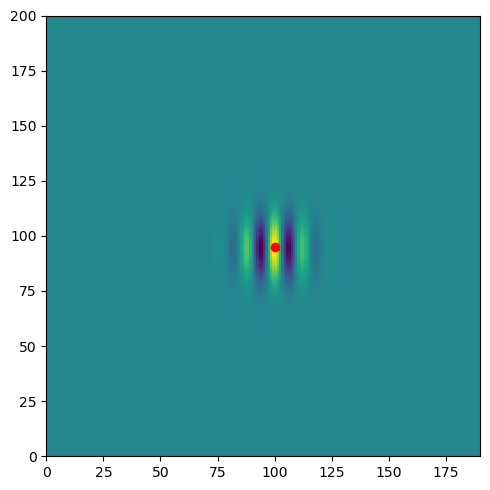

In [30]:
Nx = 200
Ny = 190
xs = np.linspace(1,Nx,Nx)
ys = np.linspace(1,Ny,Ny)
X,Y = np.meshgrid(ys,xs)

sys = system()
sys.set_geometry(Nx,Ny)
sys.set_Hamiltonian()
sys.init_wavefunction()

# Initialize the wavefunction
# i,j = 15,16
# sys.psi[i,j,sys.index] = 1

# Initialize the wavefunction with a velocity
midx, midy = Nx/2, Ny/2
print(midx, midy)
sig = 10
k = 0.5
arg = -((X-midx)**2 + (Y-midy)**2)/2/sig**2
sys.psi[:,:,sys.index] = np.exp(arg)*np.exp(1j*k*X)
sys.psi[:,:,sys.index] /= np.sqrt(np.sum(np.abs(sys.psi[:,:,sys.index])**2))

print(np.sum(np.abs(sys.psi[:,:,sys.index])**2))

fig, axs = plt.subplots(1,1,figsize=(5,5))
axs.pcolormesh(np.real(sys.psi[:,:,sys.index]))
axs.scatter(midx, midy, color="r")
plt.show()


0.9999792010311078
0.9999584026457332
0.99993760484386
0.9999168076254733
0.9998960109905576
0.9998752149390971
0.9998544194710773
0.9998336245864821
0.9998128302852961
0.999792036567504
0.9997712434330908
0.9997504508820404
0.9997296589143381
0.999708867529968
0.9996880767289149
0.9996672865111637
0.9996464968766984
0.9996257078255039
0.999604919357565
0.9995841314728661
0.9995633441713919
0.9995425574531269
0.9995217713180558
0.9995009857661632
0.9994802007974336
0.9994594164118519
0.9994386326094024
0.9994178493900696
0.9993970667538385
0.9993762847006936
0.9993555032306197
0.9993347223436011
0.9993139420396224
0.9992931623186684
0.9992723831807235
0.9992516046257727
0.9992308266538
0.9992100492647906
0.9991892724587291
0.9991684962355996
0.9991477205953871
0.9991269455380765
0.9991061710636516
0.9990853971720978
0.9990646238633993
0.9990438511375411
0.9990230789945075
0.999002307434283
0.9989815364568526
0.9989607660622003
0.9989399962503118
0.9989192270211706
0.9988984583747621
0.

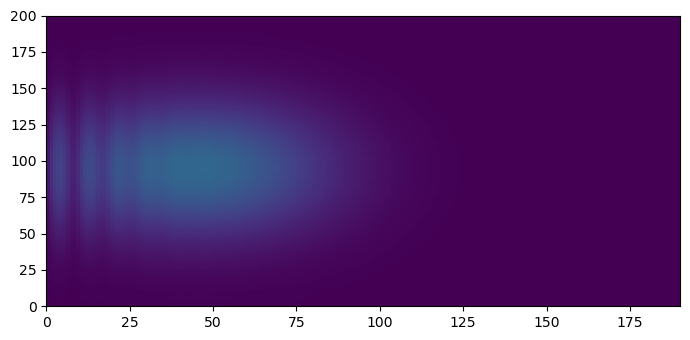

In [31]:
dt = 1.5
coefs = np.array([0,0,1])
coefs = ucoef(dt*SCALE, 15)

fig, ax = plt.subplots()
cax = ax.pcolormesh(np.abs(sys.psi[:,:,sys.index]))

def animate(i):
#for i in range(10):
    
    sys.cheb_coefs(coefs)
    
    print(np.sum(np.abs(sys.psi[:,:,sys.index])**2))
    #fig, axs = plt.subplots(1,1,figsize=(5,5))
    cax.set_array(np.abs(sys.psi[:,:,sys.index]))
    #axs.scatter(midx, midy, color="r")
    # plt.show()

anim = animation.FuncAnimation(fig, animate, interval=1, frames=100)
anim.save('517.gif')
plt.show()


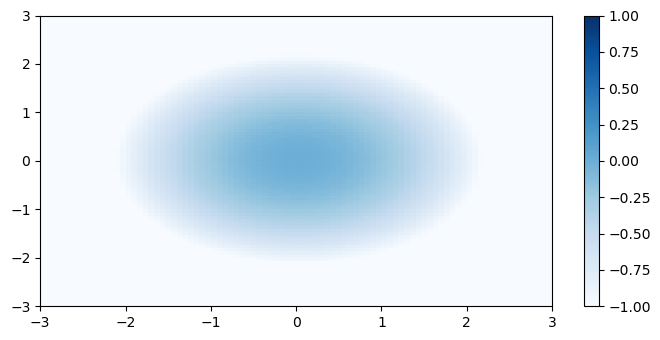

In [12]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt, animation
plt.rcParams["figure.figsize"] = [7.00, 3.50]
plt.rcParams["figure.autolayout"] = True

# x = np.linspace(-3, 3, 91)
# t = np.linspace(0, 25, 30)
# y = np.linspace(-3, 3, 91)
# X3, Y3, T3 = np.meshgrid(x, y, t)
# sinT3 = np.sin(2 * np.pi * T3 / T3.max(axis=2)[..., np.newaxis])
# G = (X3 ** 2 + Y3 ** 2) * sinT3
# cax = ax.pcolormesh(x, y, G[:-1, :-1, 0], vmin=-1, vmax=1, cmap='Blues')
# fig.colorbar(cax)



# Generate the potential to input in the C++ code

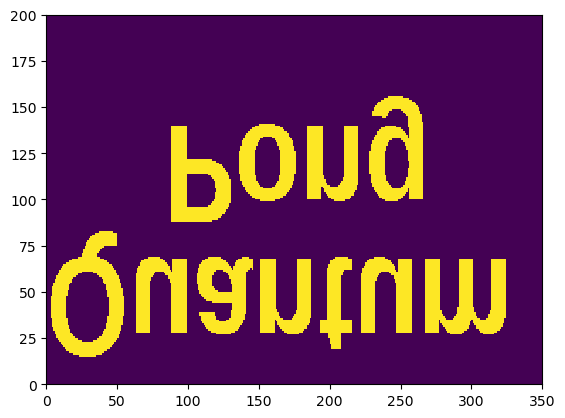

In [27]:
text = "Quantum\n    Pong"
size = (350,200)

# text = "Q"
# size = (22,11)

myfont = ImageFont.truetype("/usr/share/fonts/LiberationSans-Bold.ttf", 75)
print(myfont)
img = Image.new("1",size,"black")
draw = ImageDraw.Draw(img)
draw.text((0, 0), text, "white", font=myfont)
pixels = np.array(img, dtype=int)

plt.pcolormesh(pixels)
plt.show()
np.savetxt("qp_pot.txt", pixels, fmt='%i')